# Does MATE Encoder learn which transition is actually informative?
Experimented with T-Maze

### Environment Loading

In [113]:
import yaml
class DotDict(dict):
    """d.a 처럼 접근 가능한 dict. 중첩도 재귀로 변환."""
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

    def to_dict(self):
        def _plain(x):
            if isinstance(x, dict):
                return {k: _plain(v) for k, v in x.items()}
            if isinstance(x, list):
                return [_plain(v) for v in x]
            return x
        return _plain(self)

def to_dotdict(x):
    if isinstance(x, dict):
        return DotDict({k: to_dotdict(v) for k, v in x.items()})
    if isinstance(x, list):
        return [to_dotdict(v) for v in x]
    return x

def unwrap_value_nodes(obj):
    if isinstance(obj, dict):
        if set(obj.keys()) == {"value"}:
            return unwrap_value_nodes(obj["value"])
        return {k: unwrap_value_nodes(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [unwrap_value_nodes(x) for x in obj]
    return obj

def load_cfg(config_path):
    with open(config_path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)

    raw = unwrap_value_nodes(raw)

    # 필요한 3개만 추출
    picked = {k: raw[k] for k in ["config_env", "config_rl", "config_seq"]}

    # 점 접근 가능하게 변환
    return to_dotdict(picked)

Modify here to change directory

In [114]:
import os

log_dir = "./logs/tmaze_active/200/mate_test_128_permx_projx_lr3e-5_Huber_clip3e-2_dummy_embproj_rere_2026-01-26-22:52:46" # Example: "logs/mujoco/ant-dir/run_name_2026-01-05-17:27:32"
if log_dir == "SET_YOUR_LOG_DIR_HERE":
    raise ValueError("Please set the 'log_dir' variable to your actual log directory path.")

config_dir = os.path.join(log_dir, "wandb/latest-run/files/config.yaml")

cfg = load_cfg(config_dir)
config_env = cfg.config_env
config_rl = cfg.config_rl
config_seq = cfg.config_seq
print("Environment Config:", config_env)
print("RL Config:", config_rl)
print("Sequence Model Config:", config_seq)

Environment Config: {'env_name': 200, 'env_type': 'tmaze_active', 'eval_episodes': 64, 'eval_interval': 256, 'horizon': 'finite', 'log_interval': 128, 'n_env': 64, 'normalize_transitions': False, 'terminate_after_success': True, 'visualize_env': False, 'visualize_every': 5}
RL Config: {'algo': 'dqn', 'config_critic': {'hidden_dims': [256, 256]}, 'critic_lr': 3e-05, 'discount': 0.99, 'end_eps': 0.0049261083743842365, 'init_eps': 1, 'replay_buffer_num_episodes': 10000, 'schedule_end': 0.1, 'schedule_steps': 1624000.0, 'tau': 0.001}
Sequence Model Config: {'clip': True, 'embedder': {'hidden_sizes': [], 'norm': 'none', 'output_activation': 'leakyrelu', 'project_output': True}, 'full_transition': True, 'max_norm': 0.03, 'obs_shortcut': True, 'permutation_training': False, 'project_output': True, 'seq_model': {'hidden_size': 128, 'max_seq_length': 204, 'n_layer': 1, 'name': 'mate', 'pdrop': 0.1}, 'transition_dropout': 0}


In [115]:
import gymnasium as gym
from gymnasium.envs.registration import register
from torchkit.pytorch_utils import set_gpu_mode
env_name_fn = lambda l: f"tmaze_active_T-{l}"

seed = 42
gpu_id = 0
device = f'cuda:{gpu_id}'
set_gpu_mode(True, gpu_id)


ENTRY_POINTS = {"cheetah-vel": "envs.mujoco:HalfCheetahVelEnv", "ant-dir": "envs.mujoco:AntDirEnv", 
                "hopper-param": "envs.mujoco:HopperRandParamsEnv", "walker-param": "envs.mujoco:Walker2DRandParamsEnv",
                200: "envs.tmaze:TMazeClassicActive"}

entry_point = ENTRY_POINTS[config_env.env_name]
env_name = env_name_fn(config_env.env_name)

register(
    f"{env_name}",
    entry_point=entry_point,
    max_episode_steps=203,
    kwargs=dict(
            corridor_length=200,
            penalty=-1.0 / (200+2),  # NOTE: \sum_{t=1}^T -1/T = -1
        )
)

env = gym.make(env_name)
env.max_episode_steps = getattr(
    env, "max_episode_steps", env.spec.max_episode_steps
)
env.reset(seed=seed) # Set random seed
env.action_space.seed(seed)
env.observation_space.seed(seed)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 [0 1 1 ... 1 1 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]]


/home/hjjeong/anaconda3/envs/mate/lib/python3.10/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment tmaze_active_T-200 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


42

In [116]:
action_space = env.action_space
observation_space = env.observation_space

act_dim = action_space.n
obs_dim = observation_space.shape[0]

print("obs space", observation_space)
print("act space", action_space)
print("obs_dim", obs_dim, "act_dim", act_dim)

obs space Box(-1.0, 1.0, (3,), float32)
act space Discrete(4)
obs_dim 3 act_dim 4


### Load Policy

In [117]:
from policies.models.policy_rnn_dqn import ModelFreeOffPolicy_DQN_RNN as Policy_DQN_RNN
agent_class = Policy_DQN_RNN

agent = agent_class(
    obs_dim=obs_dim,
    action_dim=act_dim,
    config_seq=config_seq,
    config_rl=config_rl,
    freeze_critic=True,
).to(device)

Sequence model options: obs_shortcut=True, full_transition=True, project_output=True
Use permutation training: False
Transition dropout: 0


In [118]:
import torch
agent_checkpoint = torch.load(os.path.join(log_dir, "policy_checkpoint_latest.pth"), map_location=device)
agent_compile_state_dict = {}
for k, v in agent_checkpoint.items():
    # 1. 'head' 내부의 구체적인 모듈들 뒤에 _orig_mod를 삽입합니다.
    name = k.replace("observ_embedder.", "observ_embedder._orig_mod.")
    name = name.replace("transition_embedder.", "transition_embedder._orig_mod.")
    name = name.replace("seq_model.", "seq_model._orig_mod.")
    
    # 2. 예외 케이스: 'init_emb'는 에러 메시지상 _orig_mod가 붙지 않는 것으로 보입니다.
    # 만약 위 replace 과정에서 의도치 않게 바뀌었다면 다시 확인이 필요합니다.
    
    agent_compile_state_dict[name] = v
agent.load_state_dict(agent_compile_state_dict)


<All keys matched successfully>

In [119]:
def get_initial_dummies(env, obs):
    prev_obs = obs.clone()
    action = torch.FloatTensor([env.action_space.sample()]).to(device).reshape(1, -1)  # (1, A) for continuous action, (1, 1) for discrete action
    reward = torch.zeros((1, 1)).to(device)
    term = torch.zeros((1, 1)).to(device)
    return prev_obs,action,reward,term

In [120]:
def act(internal_state, action, reward, prev_obs, obs, deterministic, initial):
    action, internal_state = agent.act(
        prev_internal_state=internal_state,
        prev_action=action,
        prev_reward=reward,
        prev_obs=prev_obs,
        obs=obs,
        deterministic=deterministic,
        initial=initial,
    )
    return action, internal_state

### RollOut

In [121]:
import numpy as np

num_rollouts = 200
max_ep_len = 203
returns = []
embeddings = []
memories = []
contexts = []

print("Rollout Start")
print("Architecture:", config_seq.seq_model.name)
for rollout_idx in range(num_rollouts):
    done = False
    ep_return = 0.0
    t = 0
    obs, info = env.reset()
    obs = torch.from_numpy(obs).float().to(device).unsqueeze(0) # (1, obs_dim)
    prev_obs, action, reward, term = get_initial_dummies(env, obs)
    internal_state = None
    initial=True
    temp_embedding_cumsum=[]
    temp_memory=[]
    while not done and t < max_ep_len:
        action, internal_state = act(
            internal_state=internal_state,
            action=action,
            reward=reward,
            prev_obs=prev_obs,
            obs=obs,
            deterministic=True,
            initial=initial,
        )
        initial=False
        np_action = action.to("cpu").detach().numpy().squeeze(0) # (act_dim,)
        np_action = np.argmax(np_action)
        next_obs, reward, terminated, truncated, info = env.step(np_action)
        ep_return += reward
        next_obs = torch.from_numpy(next_obs).float().to(device).unsqueeze(0)  # (1, obs_dim)
        reward = torch.tensor([[reward]], dtype=torch.float32).to(device)  # (1, 1)
        done = terminated or truncated

        prev_obs = obs.clone()
        obs = next_obs.clone()
        t += 1
        hidden = agent.critic.head.seq_model.internal_state_to_hidden(internal_state)[0][0]
        if config_seq.project_output:
            normalized_hidden = hidden / torch.linalg.vector_norm(hidden).clamp(min=1e-6) * np.sqrt(len(hidden))
        temp_embedding_cumsum.append(hidden.detach().cpu().numpy())
        temp_memory.append(normalized_hidden.detach().cpu().numpy())
    returns.append(ep_return)
    temp_embedding=[]
    for i in range(len(temp_embedding_cumsum)):
        if i==0:
            temp_embedding.append(temp_embedding_cumsum[i])
        else:
            temp_embedding.append(temp_embedding_cumsum[i]-temp_embedding_cumsum[i-1])
    temp_embedding = np.stack(temp_embedding, axis=1)
    temp_memory = np.stack(temp_memory, axis=1)
    embeddings.append(temp_embedding)
    memories.append(temp_memory)
    contexts.append(info["context"])
    print(f"Rollout {rollout_idx + 1}/{num_rollouts}, Return: {ep_return}")

returns = np.array(returns)
memories = np.array(memories)  # (num_rollouts, hidden_size)
contexts = np.array(contexts)  # (num_rollouts, context_dim)
embeddings = np.array(embeddings)
print(f"Return over {num_rollouts} rollouts: avg {np.mean(returns)}, std {np.std(returns)}")

print(f"memories shape: {memories.shape}, contexts shape: {contexts.shape}")

Rollout Start
Architecture: mate
Rollout 1/200, Return: 1.0
Rollout 2/200, Return: 1.0
Rollout 3/200, Return: 1.0
Rollout 4/200, Return: 1.0
Rollout 5/200, Return: 1.0
Rollout 6/200, Return: 1.0
Rollout 7/200, Return: 1.0
Rollout 8/200, Return: 1.0
Rollout 9/200, Return: 1.0
Rollout 10/200, Return: 1.0
Rollout 11/200, Return: 1.0
Rollout 12/200, Return: 1.0
Rollout 13/200, Return: 1.0
Rollout 14/200, Return: 1.0
Rollout 15/200, Return: 1.0
Rollout 16/200, Return: 1.0
Rollout 17/200, Return: 1.0
Rollout 18/200, Return: 1.0
Rollout 19/200, Return: 1.0
Rollout 20/200, Return: 1.0
Rollout 21/200, Return: 1.0
Rollout 22/200, Return: 1.0
Rollout 23/200, Return: 1.0
Rollout 24/200, Return: 1.0
Rollout 25/200, Return: 1.0
Rollout 26/200, Return: 1.0
Rollout 27/200, Return: 1.0
Rollout 28/200, Return: 1.0
Rollout 29/200, Return: 1.0
Rollout 30/200, Return: 1.0
Rollout 31/200, Return: 1.0
Rollout 32/200, Return: 1.0
Rollout 33/200, Return: 1.0
Rollout 34/200, Return: 1.0
Rollout 35/200, Return: 

### Norm Analysis

Does Embedder of MATE show difference in embedding informative and uninformative transition?

(200, 203)


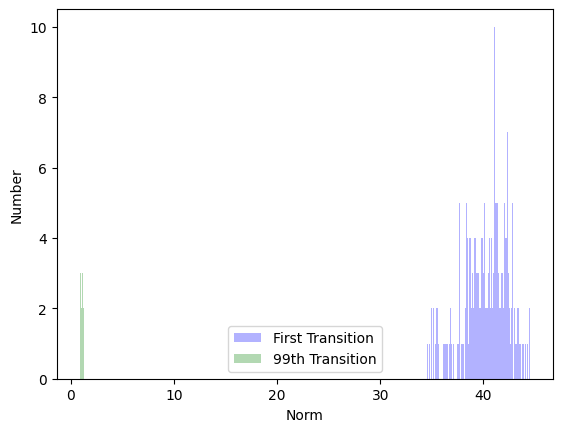

In [122]:
######## Modify to check the nth transition
check_index=100
########
embeddings_norm = np.linalg.norm(embeddings, axis=1)
print(embeddings_norm.shape)
rest_embeddings_norm = embeddings_norm[:, 2:].reshape(-1, 1)
import matplotlib.pyplot as plt
plt.hist(embeddings_norm[:,1], color='b', alpha=0.3, label='First Transition', bins=100)
plt.hist(embeddings_norm[:,check_index], color='g', alpha=0.3, label=f'{check_index-1}th Transition', bins=100)
plt.xlabel("Norm")
plt.ylabel("Number")
plt.legend()
plt.show()

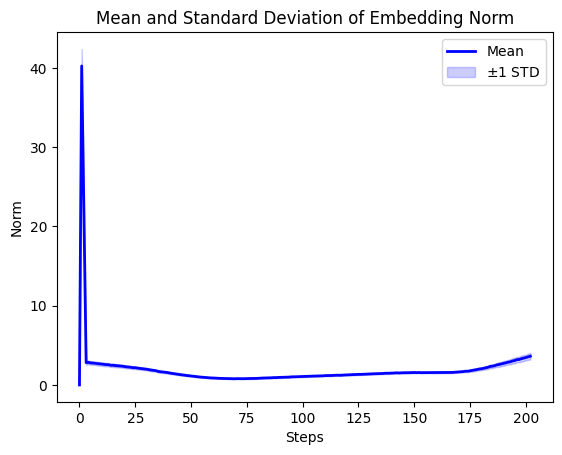

In [123]:
mean_vals = np.mean(embeddings_norm, axis=0)
std_vals = np.std(embeddings_norm, axis=0)
x = np.arange(len(mean_vals))
plt.plot(x, mean_vals, label='Mean', color='blue', linewidth=2)
plt.fill_between(x, mean_vals - std_vals, mean_vals + std_vals, 
                 color='blue', alpha=0.2, label='$\pm 1$ STD')

plt.title('Mean and Standard Deviation of Embedding Norm')
plt.xlabel('Steps')
plt.ylabel('Norm')
plt.legend()
plt.show()

How much do the uninformative transition embeddings affect the total embedding?

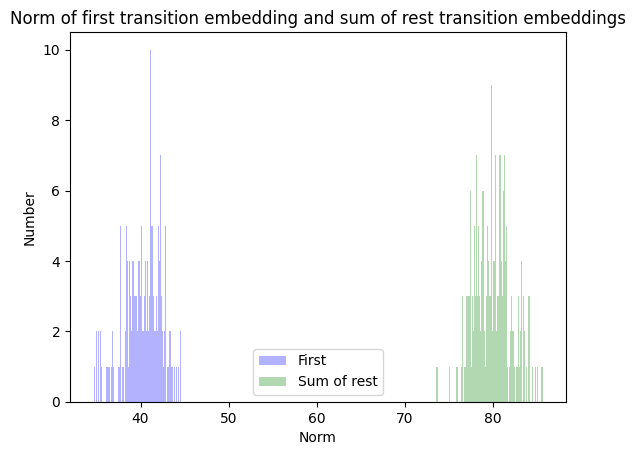

In [124]:
first_transition = embeddings[:, :, 1]
uninformative_transitions = embeddings[:, :, 2:]

total_uninformative_transitions_vector = uninformative_transitions.sum(axis=2)
first_transition_norm = np.linalg.norm(first_transition, axis=1)
total_uninformative_transitions_norm = np.linalg.norm(total_uninformative_transitions_vector, axis=1)
plt.hist(first_transition_norm, bins=100, alpha=0.3, color='b', label='First')
plt.hist(total_uninformative_transitions_norm, bins=100, alpha=0.3, color='g', label='Sum of rest')
plt.xlabel('Norm')
plt.ylabel('Number')
plt.title('Norm of first transition embedding and sum of rest transition embeddings')
plt.legend()
plt.show()

### Cosine Similarity

How much does the memory get affected by uninformative transitions? (Directionwise)

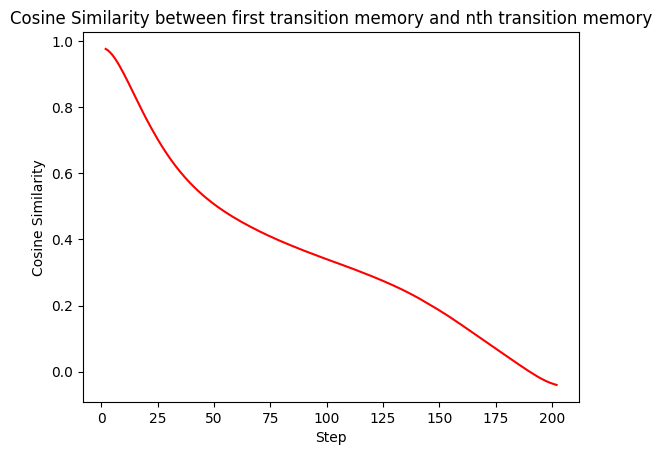

In [125]:
first_memory = memories[:,:, 1]
cossim_mean=[]
for i in range(memories.shape[2]):
    if i == 0 or i==1:
        continue
    else:
        cossim_mean.append(np.mean(np.diag(first_memory @ memories[:,:,i].T) / 128.0))
x_for_plot = np.array([i for i in range(2, memories.shape[2])])
plt.plot(x_for_plot, np.array(cossim_mean), color='r')
plt.title('Cosine Similarity between first transition memory and nth transition memory')
plt.xlabel('Step')
plt.ylabel('Cosine Similarity')
plt.show()